In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [ ]:
# Training data
train_data = datasets.FashionMNIST(
    root="fashion" ,
    train= True ,
    download= True ,
    transform= ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.50MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 140kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.58MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.0MB/s]


In [ ]:
# tesing data
test_data = datasets.FashionMNIST(
    root="fashion_test" ,
    train= False,
    download= True ,
    transform= ToTensor()

)

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.78MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 139kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.31MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.8MB/s]


In [ ]:
len(train_data) , len(test_data)

(60000, 10000)

In [ ]:
print("train classes",train_data.classes)
print("train IDX ",train_data.class_to_idx)
print("train targets" , train_data.targets)


train classes ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
train IDX  {'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
train targets tensor([9, 0, 0,  ..., 3, 0, 5])


In [ ]:
image , label=train_data[1]
image , label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000,
           0.0000, 0.0000, 0.1608, 0.7373, 0.4039, 0.2118, 0.1882, 0.1686,
           0.3412, 0.6588, 0.5216, 0.0627, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0000, 0.1922,
           0.5333, 0.8588, 0.8471, 0.8941, 0.9255, 1.0000, 1.0000, 1.0000,
           1.0000, 0.8510, 0.8431, 0.9961, 0.9059, 0.6275, 0.1765, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0549, 0.6902, 0.8706,
           0.8784, 0.8314, 0.7961, 0.7765, 0.7686, 0.7843, 0.8431, 0.8000,
           0.7922, 0.7882, 0.7882, 0.7882, 0.8196, 0.8549, 0.8784, 0.6431,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.7373, 0.8588, 0.7843,
           0.7765, 0.7922, 0.7765, 0.7804, 0.7804, 0.7882, 0.7686, 0.7765,
           0.7765, 0.7843, 0.7843, 0.7843, 

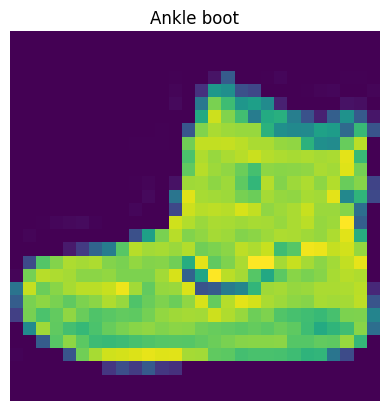

In [ ]:
# Showing image
image , label =train_data[0]
plt.imshow(image.squeeze())
plt.title(train_data.classes[label])
plt.axis(False)
plt.show()

In [ ]:
torch.manual_seed(42)
fig=plt.figure(figsize=(10,10))
rows , cols = 4 , 4
for i in range(1 , rows * cols +1 ):
  random_index = torch.randint(0 , len(train_data),size= [1]).item()
  image  ,  label = train_data[random_index]
  fig.add_subplot(rows , cols , i )
  plt.imshow(image.squeeze())
  plt.title(train_data.classes[label])
  plt.axis(False)

NameError: name 'torch' is not defined

In [ ]:
from torchvision.datasets.vision import data
 # loading  the data
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data , batch_size= 32 , shuffle= True)
test_dataloader = DataLoader( test_data , batch_size= 32 , shuffle= True)

print(f"lenth of the train dataloader {len(train_dataloader)} with batch size {train_dataloader.batch_size}")
print(f"lenth of the test dataloader {len(test_dataloader)} with   batch size {test_dataloader.batch_size}"  )


lenth of the train dataloader 1875 with batch size 32
lenth of the test dataloader 313 with   batch size 32


In [ ]:
train_feature_batch , train_label_batch = next(iter(train_dataloader))
train_feature_batch.shape , train_label_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

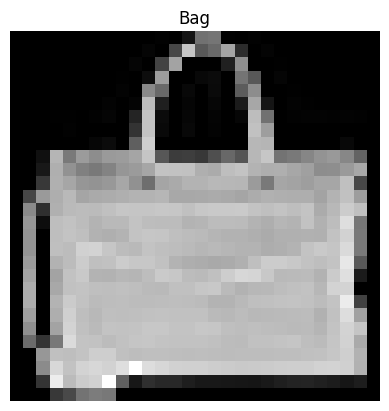

In [ ]:
#torch.manual_seed(42)
random_idx = torch.randint(0 , len(train_feature_batch), size= [1]).item()
image , label = train_feature_batch[random_idx], train_label_batch[random_idx]
plt.axis(False)
plt.imshow(image.squeeze(), cmap='grey')
plt.title(train_data.classes[label])
plt.show()


In [ ]:
# work of flatten layer
flatten_mod= nn.Flatten()
x= train_feature_batch[0]
lay= flatten_mod(x)
lay.shape , x.shape  # flatten layer just multiply the height * width



(torch.Size([1, 784]), torch.Size([1, 28, 28]))

In [ ]:
# create the model
class fashionmodel(nn.Module):
  def __init__(self,input_shape: int  , hidden_shape: int  , output_shape : int  ) :
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape , out_features=hidden_shape),
        nn.Linear(in_features=hidden_shape , out_features= output_shape)
    )
  def forward(self , x):
      return self.layer_stack(x)


In [ ]:
torch.manual_seed(42)
model_1 = fashionmodel(input_shape=28 * 28 , hidden_shape=10 , output_shape=10).to("cpu")
model_1

fashionmodel(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
dummy = torch.rand(1,1, 28, 28)
model_1(dummy)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [ ]:
model_1.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

In [ ]:
#loss + optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params= model_1.parameters(), lr= 0.1)


In [ ]:
 # timer
from timeit import default_timer as timer
def print_timer(start: float , end: float , device: torch.device = None):
  total_time= start - end
  print(f"Train time on {device} : {total_time:.3f} seconds")
  return total_time

In [ ]:
epochs = 3
from tqdm.auto import tqdm
torch.manual_seed(42)
for epoch in tqdm(range(epochs)):

    train_loss = 0
    model_1.train()

    for X, y in train_dataloader:
        y_pred = model_1(X)
        loss = loss_fn(y_pred, y)

        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_dataloader)

    # Testing
    test_loss = 0
    test_acc = 0
    model_1.eval()

    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            test_pred = model_1(X_test)

            test_loss += loss_fn(test_pred, y_test).item()
            test_acc += accuracy_score(
                y_test.cpu(),
                test_pred.argmax(dim=1).cpu()
            )

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

    print(f"Epoch {epoch+1} | "
          f"Train loss: {train_loss:.4f} | "
          f"Test loss: {test_loss:.4f} | "
          f"Test acc: {test_acc:.4f}")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1 | Train loss: 0.5904 | Test loss: 0.5102 | Test acc: 0.8204
Epoch 2 | Train loss: 0.4743 | Test loss: 0.5268 | Test acc: 0.8168
Epoch 3 | Train loss: 0.4537 | Test loss: 0.5126 | Test acc: 0.8300


In [ ]:
# model evaluation
acc, loss = 0 , 0

model_1.eval()
with torch.inference_mode():
  for X_test , Y_test in test_dataloader:
    test_pred  =  model_1(X_test)
    loss += loss_fn(test_pred , Y_test)
    acc += accuracy_score(Y_test , test_pred.argmax(dim=1))

  avg_acc = acc/ len(test_dataloader)
  avg_loss = loss/ len(test_dataloader)

print(f"model accuracy {avg_acc}")
print(f"model loss {avg_loss}")


model accuracy 0.8300718849840255
model loss 0.5124600529670715


In [ ]:
# device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
# model with gpu
model_2 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=28 * 28 , out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10 , out_features=10),
    nn.ReLU()
).to(device)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params= model_2.parameters(), lr= 0.1)

In [ ]:
# traing loop for not linear
start_time = timer()
epochs = 3
for epoch in tqdm(range(epochs)):
  model_2.train()
  train_loss = 0
  for X, y in train_dataloader:
    X= X.to(device)
    y= y.to(device)
    y_pred = model_2(X)
    loss = loss_fn(y_pred , y )
    train_loss += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_loss = train_loss / len(train_dataloader)

  model_2.eval()
  with torch.inference_mode():
    test_loss_epoch = 0
    test_acc_epoch = 0
    for X , y in test_dataloader:
      X= X.to(device)
      y= y.to(device)
      test_pred = model_2(X)
      loss = loss_fn(test_pred , y)
      test_loss_epoch += loss.item()

      test_acc_epoch += accuracy_score(y.cpu() ,test_pred.argmax(dim=1).cpu())
    test_loss_epoch = test_loss_epoch / len(test_dataloader)
    test_acc_epoch = test_acc_epoch / len(test_dataloader)

    print(f"Epoch {epoch+1} | "
          f"Train loss: {train_loss:.4f} | "
          f"Test loss: {test_loss_epoch:.4f} | "
          f"Test acc: {test_acc_epoch:.4f}")
    end_time = timer()
  print(end_time - start_time)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1 | Train loss: 1.0308 | Test loss: 0.9437 | Test acc: 0.6761
10.599711576999994
Epoch 2 | Train loss: 0.8908 | Test loss: 0.9253 | Test acc: 0.6605
20.691197207999977
Epoch 3 | Train loss: 0.8634 | Test loss: 0.7715 | Test acc: 0.7411
33.70358220999998


In [ ]:
from torch.nn.modules import padding

class fashionmodel2(nn.Module):
  def __init__(self,input_shape: int  , hidden_shape: int  , output_shape : int  ) :
    super().__init__()
    self.covt_block1= nn.Sequential(
        nn.Conv2d(in_channels=input_shape , out_channels=hidden_shape , kernel_size=3 , stride=1 , padding= 1 ),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_shape , out_channels= hidden_shape , kernel_size = 3 , stride =1 , padding= 1 ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2 , )
        )
    self.covt_block2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_shape , out_channels= hidden_shape , kernel_size=3 , padding=1 ),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_shape , out_channels= hidden_shape , kernel_size=3 ,padding=1 ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_shape * 7 * 7, out_features= output_shape)

    )
  def forward(self , x):
      x=self.covt_block1(x)

      x= self.covt_block2(x)

      x= self.classifier(x)

      return x


In [ ]:
torch.manual_seed(42)
model_3 = fashionmodel2(input_shape=1 , hidden_shape=10 , output_shape=10).to(device)


In [ ]:
torch.manual_seed(42)
images = torch.randn(size=(32 , 3 , 64 ,64 ))
test_image= images[0]
images.shape , test_image.shape , test_image

(torch.Size([32, 3, 64, 64]),
 torch.Size([3, 64, 64]),
 tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
          [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
          [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
          ...,
          [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
          [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
          [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],
 
         [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
          [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
          [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
          ...,
          [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
          [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
          [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],
 
         [[-0.7978,  1.0261,  1.1465,  ..., 

In [ ]:
single= nn.Conv2d(in_channels=3 , out_channels=10 , kernel_size = 3 , stride=1 , padding = 0 )
single(test_image)

tensor([[[-0.4659, -1.5799, -1.2944,  ..., -0.5303,  1.1141, -1.3103],
         [ 0.4850,  0.3620,  0.6290,  ..., -0.3023,  0.4242, -0.2906],
         [-0.6028, -0.1594,  0.7972,  ...,  0.9343, -0.4367,  0.4471],
         ...,
         [ 0.6457, -0.3963,  0.5281,  ..., -0.0508, -0.6285, -0.6875],
         [ 0.4539, -0.2911,  0.8101,  ..., -0.6718,  0.6624, -0.6925],
         [-0.8265, -0.2912,  0.1314,  ..., -0.3609,  0.6440, -0.4856]],

        [[-0.0169,  0.2329, -0.4267,  ...,  1.4123,  0.3158,  0.0389],
         [-0.4644, -0.6841,  0.5292,  ..., -0.1784, -0.3034,  0.4061],
         [-0.4367,  1.0783,  0.3114,  ..., -0.0100,  0.0520,  0.9570],
         ...,
         [-1.2828, -0.7328,  0.2151,  ...,  0.2507,  0.0299, -0.1049],
         [ 0.3095,  0.6570, -0.6916,  ...,  0.8615, -0.1190,  0.8467],
         [ 0.8406,  0.3599,  1.2418,  ...,  0.5633, -1.3168, -0.2853]],

        [[-0.5620, -1.1078,  0.0464,  ..., -0.0352, -0.3132,  0.2098],
         [-0.3292,  0.1821,  0.3540,  ..., -0

In [ ]:
rand_tensor = torch.randn(size=(1,28, 28))
rand_tensor.shape

torch.Size([1, 28, 28])

In [ ]:
model_3(rand_tensor.unsqueeze(0).to(device))

tensor([[ 0.0429, -0.0882,  0.0711, -0.0426,  0.0138,  0.0316,  0.0028,  0.0014,
         -0.0044, -0.0047]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [ ]:
# loss  + optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_3.parameters(), lr=0.1 )

In [ ]:
start_time = timer()
epochs = 3
for epoch in tqdm(range(epochs)):
  model_3.train()
  train_loss = 0
  for X, y in train_dataloader:
    X= X.to(device)
    y= y.to(device)
    y_pred = model_2(X)
    loss = loss_fn(y_pred , y )
    train_loss += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_loss = train_loss / len(train_dataloader)

  model_2.eval()
  with torch.inference_mode():
    test_loss_epoch = 0
    test_acc_epoch = 0
    for X , y in test_dataloader:
      X= X.to(device)
      y= y.to(device)
      test_pred = model_2(X)
      loss = loss_fn(test_pred , y)
      test_loss_epoch += loss.item()

      test_acc_epoch += accuracy_score(y.cpu() ,test_pred.argmax(dim=1).cpu())
    test_loss_epoch = test_loss_epoch / len(test_dataloader)
    test_acc_epoch = test_acc_epoch / len(test_dataloader)

    print(f"Epoch {epoch+1} | "
          f"Train loss: {train_loss:.4f} | "
          f"Test loss: {test_loss_epoch:.4f} | "
          f"Test acc: {test_acc_epoch:.4f}")
    end_time = timer()
  print(end_time - start_time)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1 | Train loss: 0.7338 | Test loss: 0.7714 | Test acc: 0.7412
10.531862615000136
Epoch 2 | Train loss: 0.7338 | Test loss: 0.7710 | Test acc: 0.7414
21.298872905999815
Epoch 3 | Train loss: 0.7338 | Test loss: 0.7711 | Test acc: 0.7411
32.003279311999904
